In [59]:
#Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 
from sklearn.preprocessing import StandardScaler

In [60]:
file_path = 'data_shopping_trends.csv'
df = pd.read_csv('data_shopping_trends.csv')
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [61]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   str    
 3   Item Purchased            3900 non-null   str    
 4   Category                  3900 non-null   str    
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   str    
 7   Size                      3900 non-null   str    
 8   Color                     3900 non-null   str    
 9   Season                    3900 non-null   str    
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   str    
 12  Payment Method            3900 non-null   str    
 13  Shipping Type             3900 non-null   str    
 14  Discount Applied   

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

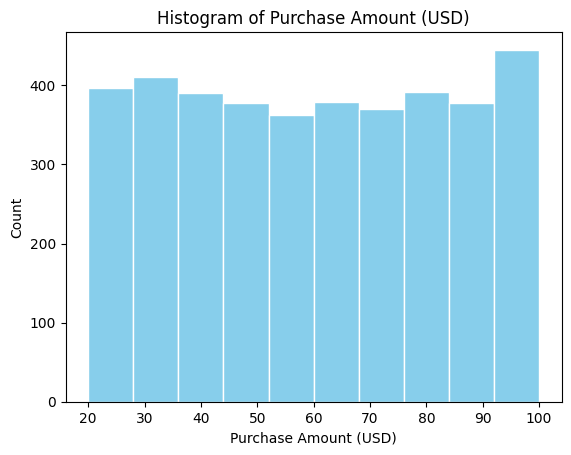

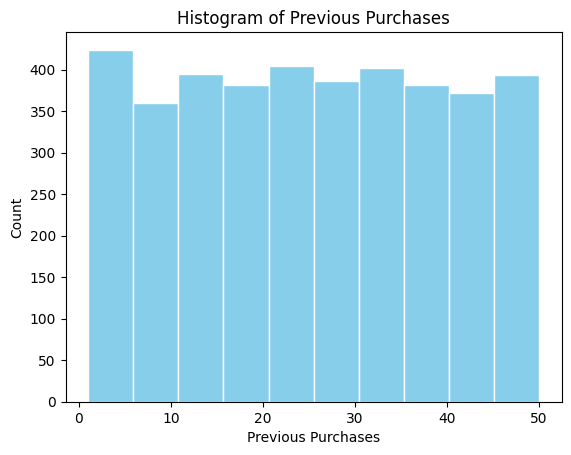

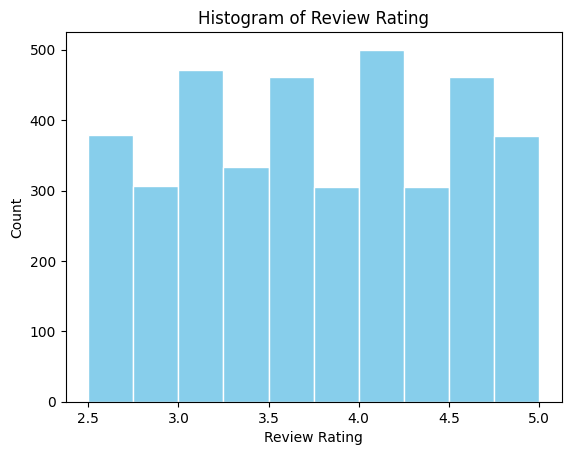

In [62]:
numeric_cols=['Purchase Amount (USD)','Previous Purchases','Review Rating']
for col in numeric_cols:
    plt.hist(df[col], bins= 10, color='skyblue',edgecolor='white')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel(col)
    plt.ylabel ('Count')
    plt.show() 

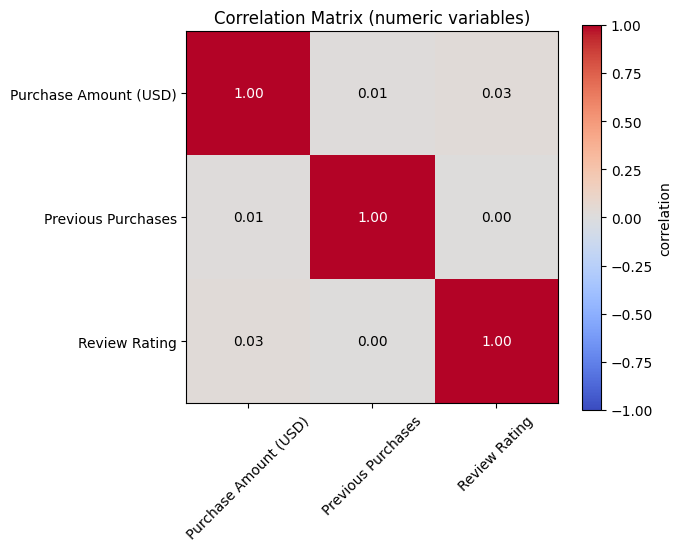

In [63]:
corr = df[numeric_cols].corr()
#ma trận
plt.figure(figsize=(6,5))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='correlation')

plt.xticks(range(len(numeric_cols)), numeric_cols, rotation =45)
plt.yticks(range(len(numeric_cols)), numeric_cols)
# Hiển thị số
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        plt.text(j,i,f"{corr.iloc[i,j]:.2f}", ha= 'center', va='center', color='white' if abs(corr.iloc[i,j])>0.5 else 'black')
plt.title('Correlation Matrix (numeric variables)')
plt.show()


In [64]:
#Chuẩn hóa biến numeric
from sklearn.preprocessing import StandardScaler
df_numeric = df[numeric_cols].copy()
scaler = StandardScaler()
df_numeric_scaled = pd. DataFrame(scaler.fit_transform (df_numeric), columns= numeric_cols)
df_numeric_scaled.head()


,Purchase Amount (USD),Previous Purchases,Review Rating
0,-0.285629,-0.785831,-0.907584
1,0.178852,-1.616552,-0.907584
2,0.558882,-0.162789,-0.907584
3,1.276716,1.637107,-0.349027
4,-0.454531,0.391025,-1.466141


In [65]:
from sklearn.preprocessing import LabelEncoder
target_col = 'Subscription Status'
le = LabelEncoder()
df[target_col + '_encoded'] = le.fit_transform(df[target_col])
df[[target_col, target_col +'_encoded']].head()


,Subscription Status,Subscription Status_encoded
0,Yes,1
1,Yes,1
2,Yes,1
3,Yes,1
4,Yes,1


In [ ]:
categorical_cols = [
    'Payment Method',
    'Shipping Type',
    'Promo Code Used',
    'Preferred Payment Method',
    'Frequency of Purchases'
]

df_categorical = df[categorical_cols].copy()
df_categorical_encoded = pd.get_dummies(df_categorical, drop_first=True)
df_categorical_encoded.head()

,Payment Method_Cash,Payment Method_Credit Card,Payment Method_Debit Card,Payment Method_PayPal,Payment Method_Venmo,Shipping Type_Express,Shipping Type_Free Shipping,Shipping Type_Next Day Air,Shipping Type_Standard,Shipping Type_Store Pickup,...,Preferred Payment Method_Credit Card,Preferred Payment Method_Debit Card,Preferred Payment Method_PayPal,Preferred Payment Method_Venmo,Frequency of Purchases_Bi-Weekly,Frequency of Purchases_Every 3 Months,Frequency of Purchases_Fortnightly,Frequency of Purchases_Monthly,Frequency of Purchases_Quarterly,Frequency of Purchases_Weekly
0,False,True,False,False,False,True,False,False,False,False,...,False,False,False,True,False,False,True,False,False,False
1,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,True,False,False,False,False,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True
3,False,False,False,True,False,False,False,True,False,False,...,False,False,True,False,False,False,False,False,False,True
4,True,False,False,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,False,False,False


In [67]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier 
from sklearn.neural_network import MLPClassifier 
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, matthews_corrcoef, roc_curve

x= pd.concat([df_numeric_scaled, df_categorical_encoded], axis=1) 
y= df['Subscription Status_encoded'] 
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.25, random_state=42, stratify=y)
                                                    




d:\Python Project\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


                 Model  Accuracy  F1 Score  Precision    Recall   ROC AUC  \
0  Logistic Regression  0.843077  0.763524   0.643229  0.939163  0.903619   
1                  SVM  0.845128  0.764431   0.648148  0.931559  0.898001   
3       Neural Network  0.797949  0.627599   0.624060  0.631179  0.897365   
2        Decision Tree  0.807179  0.629921   0.653061  0.608365  0.744491   

        MCC  
0  0.678317  
1  0.678425  
3  0.488985  
2  0.500342  


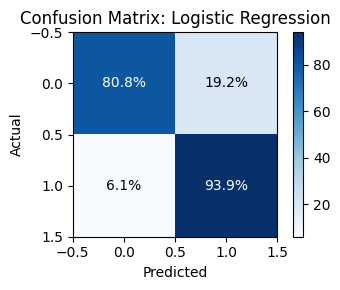

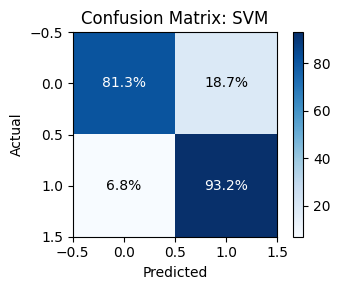

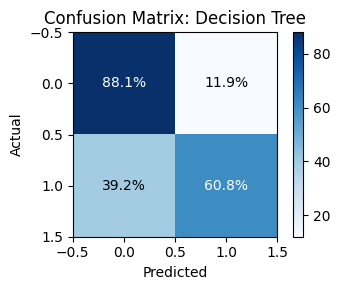

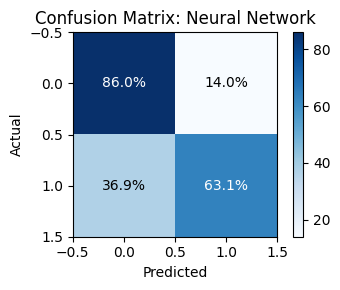

In [ ]:
# Khởi tạo các mô hình
models={
    'Logistic Regression': LogisticRegression(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Neural Network': MLPClassifier(random_state=42, max_iter=500)
}
# Train và đánh giá từng mô hình
results = []
for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred= model.predict(x_test)
    y_proba = model.predict_proba(x_test)[:,1]
    y_proba_no = 1 - y_proba

    acc= accuracy_score(y_test, y_pred)
    f1= f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall= recall_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    mcc = matthews_corrcoef(y_test, y_pred)

    results.append({
        'Model': name,
        'Accuracy': acc,
        'F1 Score': f1,
        'Precision': precision,
        'Recall': recall,
        'ROC AUC': roc_auc,
        'MCC': mcc,
        'y_pred': y_pred,
        'y_proba': y_proba
    })

#Hiển thị bảng metrics
df_results = pd.DataFrame(results)
metrics_cols = ['Model','Accuracy','F1 Score','Precision','Recall','ROC AUC','MCC']
print(df_results[metrics_cols].sort_values(by='ROC AUC', ascending=False))

# Vẽ Confusion Maxtrix
for res in results:
    cm = confusion_matrix(y_test, res['y_pred'])

    # Tính phần trăm theo từng dòng Actual
    # Nghĩa là: trong mỗi lớp thực tế, mô hình dự đoán đúng/sai bao nhiêu %
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    plt.figure(figsize=(4, 3))
    plt.imshow(cm_percent, cmap='Blues')
    plt.colorbar()

    plt.title(f'Confusion Matrix: {res["Model"]}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')


    for i in range(cm_percent.shape[0]):
        for j in range(cm_percent.shape[1]):
            plt.text(
                j, i,
                f"{cm_percent[i, j]:.1f}%",
                ha='center',
                va='center',
                color='white' if cm_percent[i, j] > 50 else 'black'
            )

    plt.tight_layout()



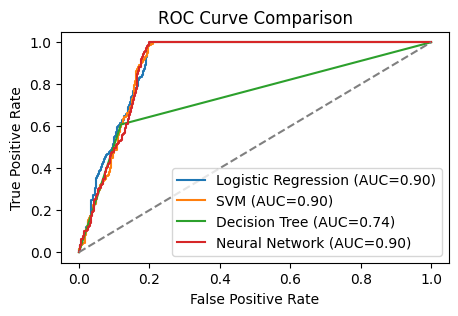

In [69]:
# --- 9. VẼ ROC CURVE OVERLAY 4 MÔ HÌNH ---
plt.figure(figsize=(5,3))
for res in results:
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    plt.plot(fpr, tpr, label=f"{res['Model']} (AUC={res['ROC AUC']:.2f})")

plt.plot([0,1],[0,1],'--', color='grey')  # đường chéo
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

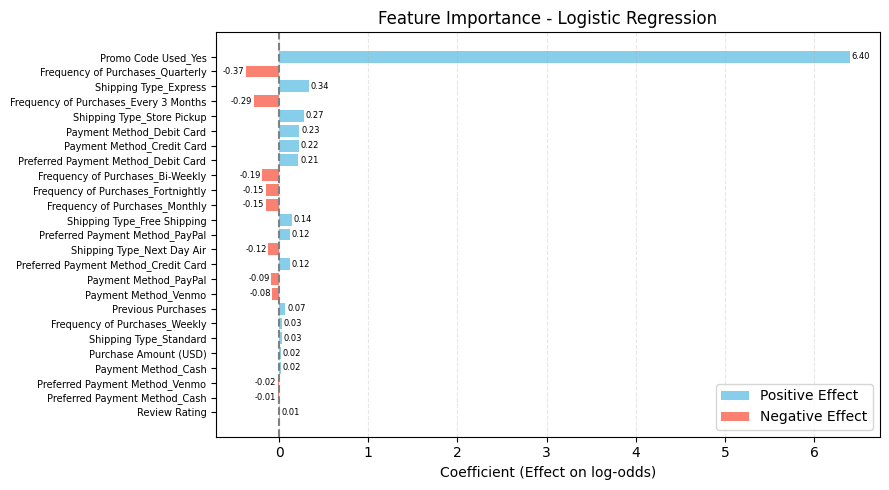

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression
model = LogisticRegression(random_state=42)
model.fit(x, y)

coefs = model.coef_[0]
features = x.columns.tolist()

# Sắp xếp theo giá trị tuyệt đối giảm dần
abs_coefs = np.abs(coefs)
sorted_idx = np.argsort(abs_coefs)[::-1]
sorted_features = [features[i] for i in sorted_idx]
sorted_coefs = coefs[sorted_idx]

colors = ['skyblue' if c >=0 else 'salmon' for c in sorted_coefs]

plt.figure(figsize=(9,5))
bars = plt.barh(sorted_features, sorted_coefs, color=colors)
plt.axvline(0, color='grey', linestyle='--')

plt.gca().invert_yaxis()
plt.yticks(fontsize=7)

for bar in bars:
    width = bar.get_width()
    plt.text(width + np.sign(width)*0.02, bar.get_y() + bar.get_height()/2,
             f"{width:.2f}", va='center', ha='left' if width>=0 else 'right', fontsize=6)

plt.xlabel("Coefficient (Effect on log-odds)")
plt.title("Feature Importance - Logistic Regression")
plt.grid(axis='x', linestyle='--', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='skyblue', label='Positive Effect'),
                   Patch(facecolor='salmon', label='Negative Effect')]
plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()